# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

The dataset I chose was the smart supply chain data from DataCo:https://www.kaggle.com/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis?select=DescriptionDataCoSupplyChain.csv. The data provides purchase information like the product name, type of transaction, delivery status, late delivery risk, customer information like where they live, and details on the product like its description and category ID. 

Who: My target audience will be the delivery operations team who decides how to prioritize orders adn select shipping options for its products. 

What: Identify what products, region or specific stores, and shipping methods most associated with late deliveries, and take action by adjusting shipping decisions or prioritizing high risk orders. For shipping, the shipping mode or carrier can be adjusted. 

How: I would create a chart with the order ID taht had the most at late delivery risk to show the problem areas. I would then use a bar chart to identify if specific department stores were vulnerable to operational bottleneck. I would then finish with recommendation like change shipping modes for specific regions or flag high risk orders and review the delivery procedure. 

# 3. Homework - work with your own data

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

In [2]:
df_flight_dataset = pd.read_csv("flight_data.csv", encoding="latin1") #asked chatGPT for help on why sep through "," was not working
#df_supply_chain_dataset.head()
#I chose to limit some of the columns of data so that I could see it all when I did my code . I limited to columns that would impact delivery
print(df_flight_dataset.describe())
#adjusted the format as it would cause errors for the median, mode, and median calculations. 
#df_delivery = df_flight_dataset[["Days for shipping (real)","Days for shipment (scheduled)","Late_delivery_risk","Department Id","Order Item Quantity","Sales","Order Item Total","Product Status","shipping date (DateOrders)"]].copy()
#df_delivery["shipping date (DateOrders)"] = pd.to_datetime(df_delivery["shipping date (DateOrders)"], format='%m/%d/%Y', errors="coerce")
#df_delivery.describe()

         DayOfWeek      DepTime      ArrTime   CRSArrTime    FlightNum  \
count  9999.000000  9999.000000  9999.000000  9999.000000  9999.000000   
mean      4.498750  1635.765277  1682.184418  1700.532553  1477.461646   
std       1.849286   401.428417   549.661808   451.725470  1123.057776   
min       1.000000     9.000000     1.000000     5.000000     3.000000   
25%       4.000000  1343.000000  1432.000000  1435.000000   511.000000   
50%       5.000000  1706.000000  1810.000000  1755.000000  1231.000000   
75%       6.000000  1951.000000  2103.000000  2040.000000  2360.000000   
max       7.000000  2358.000000  2400.000000  2355.000000  3953.000000   

       ActualElapsedTime  CRSElapsedTime      AirTime     ArrDelay  \
count        9999.000000     9999.000000  9999.000000  9999.000000   
mean          106.071107      107.014701    88.594759    45.906291   
std            54.863794       55.700219    53.294862    36.307346   
min            36.000000       45.000000    25.000000

Here I identify any other inconsistent data. 
Some inconsistent information I found are some of the shipping days scheduled and that are real have 0 day shipments which does not make sense. I also see a big outlier with benefit per order and order profit order with a value of -783, which I imagine should not be a negative value. I also found that there are no product descriptions and all the values in product status is 0. 

In [3]:
df_flight_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   DayOfWeek          9999 non-null   int64 
 1   Date               9999 non-null   object
 2   DepTime            9999 non-null   int64 
 3   ArrTime            9999 non-null   int64 
 4   CRSArrTime         9999 non-null   int64 
 5   UniqueCarrier      9999 non-null   object
 6   Airline            9999 non-null   object
 7   FlightNum          9999 non-null   int64 
 8   TailNum            9999 non-null   object
 9   ActualElapsedTime  9999 non-null   int64 
 10  CRSElapsedTime     9999 non-null   int64 
 11  AirTime            9999 non-null   int64 
 12  ArrDelay           9999 non-null   int64 
 13  DepDelay           9999 non-null   int64 
 14  Origin             9999 non-null   object
 15  Org_Airport        9999 non-null   object
 16  Dest               9999 non-null   object


In [4]:
#Identify if there are any duplicates 
#duplicate_rows = df_delivery.duplicated().sum()
#print(duplicate_rows)
#there are no duplicates within this dataset. 
df_flight_dataset.duplicated().sum()
#checked the rest of the column as well but no duplicates 

np.int64(0)

In [5]:
#Here I get the mean, median, and mode
df_flight = df_flight_dataset[["DepTime","ArrTime","Distance","TaxiIn","Cancelled","Diverted","CarrierDelay","WeatherDelay","LateAircraftDelay"]].copy()
df_mean = df_flight.mean()
df_mean

DepTime              1635.765277
ArrTime              1682.184418
Distance              599.194119
TaxiIn                  5.153815
Cancelled               0.000000
Diverted                0.000000
CarrierDelay           10.851685
WeatherDelay            1.582258
LateAircraftDelay      27.946595
dtype: float64

In [6]:
df_median = df_flight.median()
df_median

DepTime              1706.0
ArrTime              1810.0
Distance              414.0
TaxiIn                  4.0
Cancelled               0.0
Diverted                0.0
CarrierDelay            4.0
WeatherDelay            0.0
LateAircraftDelay      19.0
dtype: float64

In [7]:
df_mode = df_flight.mode()
df_mode


,DepTime,ArrTime,Distance,TaxiIn,Cancelled,Diverted,CarrierDelay,WeatherDelay,LateAircraftDelay
0,2004,2235,337,4,0,0,0,0,0


In [8]:
#Find null or na values
print(df_flight_dataset.isna().sum())
#print(df_supply_chain_dataset.isnull().sum())
#Missing values for order zipcode and product description
#converted the na values to 0 to show that they are missing values for the statistic. I did not remove the
#data as that would remove almost all the data. However for product description, it will not mattter with making those values 0 as all values were missing
df_flight_dataset.fillna(0)


DayOfWeek            0
Date                 0
DepTime              0
ArrTime              0
CRSArrTime           0
UniqueCarrier        0
Airline              0
FlightNum            0
TailNum              0
ActualElapsedTime    0
CRSElapsedTime       0
AirTime              0
ArrDelay             0
DepDelay             0
Origin               0
Org_Airport          0
Dest                 0
Dest_Airport         0
Distance             0
TaxiIn               0
TaxiOut              0
Cancelled            0
CancellationCode     0
Diverted             0
CarrierDelay         0
WeatherDelay         0
NASDelay             0
SecurityDelay        0
LateAircraftDelay    0
dtype: int64


,DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,UniqueCarrier,Airline,FlightNum,TailNum,ActualElapsedTime,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,4,3/1/2019,1829,1959,1925,WN,Southwest Airlines Co.,3920,N464WN,90,...,3,10,0,N,0,2,0,0,0,32
1,4,3/1/2019,1937,2037,1940,WN,Southwest Airlines Co.,509,N763SW,240,...,3,7,0,N,0,10,0,0,0,47
2,4,3/1/2019,1644,1845,1725,WN,Southwest Airlines Co.,1333,N334SW,121,...,6,8,0,N,0,8,0,0,0,72
3,4,3/1/2019,1452,1640,1625,WN,Southwest Airlines Co.,675,N286WN,228,...,7,8,0,N,0,3,0,0,0,12
4,4,3/1/2019,1323,1526,1510,WN,Southwest Airlines Co.,4,N674AA,123,...,4,9,0,N,0,0,0,0,0,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,1,21-01-2019,2007,2200,2055,WN,Southwest Airlines Co.,3936,N284WN,113,...,3,12,0,N,0,2,0,0,0,63
9995,1,21-01-2019,2153,2355,2155,WN,Southwest Airlines Co.,2036,N289CT,122,...,5,12,0,N,0,0,0,0,0,120
9996,1,21-01-2019,2225,2319,2300,WN,Southwest Airlines Co.,1836,N226WN,54,...,3,9,0,N,0,10,0,4,0,5
9997,1,21-01-2019,1841,2058,2040,WN,Southwest Airlines Co.,632,N714CB,137,...,4,11,0,N,0,1,0,0,0,17


In [18]:
#Using one hot encoding to adjust some of the category of data

#Adjusted the shipping mode to use ints 
unique=df_flight_dataset["Org_Airport"].unique
df_flight_fixed = df_flight_dataset
one_hot = pd.get_dummies(df_flight_dataset["Org_Airport"], dtype=int)
df_flight_fixed = df_flight_dataset.join(one_hot)
df_flight_fixed.iloc[0:5]

#Adjusted the delivery status to use ints 
#df_supply_fixed = df_supply_chain_dataset.drop(columns=df_supply_chain_dataset["Delivery Status"].unique(), errors="ignore")
#one_hot = pd.get_dummies(df_supply_chain_dataset["Delivery Status"], dtype=int)
#df_supply_fixed = df_supply_chain_dataset.join(one_hot)
#df_supply_fixed.iloc[0:5]




,DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,UniqueCarrier,Airline,FlightNum,TailNum,ActualElapsedTime,...,Spokane International Airport,St. Louis International Airport at Lambert Field,Tampa International Airport,Theodore Francis Green State Airport,Tucson International Airport,Tulsa International Airport,Valley International Airport,Washington Dulles International Airport,Will Rogers World Airport,William P. Hobby Airport
0,4,3/1/2019,1829,1959,1925,WN,Southwest Airlines Co.,3920,N464WN,90,...,0,0,0,0,0,0,0,0,0,0
1,4,3/1/2019,1937,2037,1940,WN,Southwest Airlines Co.,509,N763SW,240,...,0,0,0,0,0,0,0,0,0,0
2,4,3/1/2019,1644,1845,1725,WN,Southwest Airlines Co.,1333,N334SW,121,...,0,0,0,0,0,0,0,0,0,0
3,4,3/1/2019,1452,1640,1625,WN,Southwest Airlines Co.,675,N286WN,228,...,0,0,0,0,0,0,0,0,0,0
4,4,3/1/2019,1323,1526,1510,WN,Southwest Airlines Co.,4,N674AA,123,...,0,0,0,0,0,0,0,0,0,0


In [19]:
#Check for categorical imbalances

#asked google how to check the values of a column of  data with panda dataframe using python
tailnum_mode = df_flight_dataset["TailNum"].value_counts(dropna=False)
print(tailnum_mode)
counts_taxiout = df_flight_dataset["TaxiOut"].value_counts(dropna=False)
print(counts_taxiout)
cancellation_code = df_flight_dataset["CancellationCode"].value_counts(dropna=False)
print(cancellation_code)

TailNum
N325SW    43
N693SW    42
N692SW    42
N301SW    40
N378SW    39
          ..
N244WN     5
N620SW     4
N467WN     3
N657SW     2
N300SW     1
Name: count, Length: 513, dtype: int64
TaxiOut
8     1248
9     1150
7     1107
10    1067
11     821
      ... 
62       1
76       1
75       1
71       1
73       1
Name: count, Length: 77, dtype: int64
CancellationCode
N    9999
Name: count, dtype: int64


Conclusion
- Are the data usable?  If not, find some new data! 
The dataset is usable for exploratory analysis of flight operations and delays. The dataset has numerous rows and columns with a mix of numeric data and string data like ariline and airports. Most columns show non-null values so no major missing data. 

- Do you need to modify or correct the data in some way?
I did not modify or correct the data but the time fileds (DepTime and ArrTime) should be adjusted to represent clock time as they are formated as an int. Based on the checks there was no missing or duplicate values. 

- Is there any class imbalance?  (Categories that have many more items than other categories).
There was some imbalance with the data I collected as I was only able to put 10000 datapoints as python was not able to handle the full dataset. The cancellationCode was almost dominated by one single value in the output showed. The TailNum alsow shoed up many times compared to other aircrafts. 

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data. Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

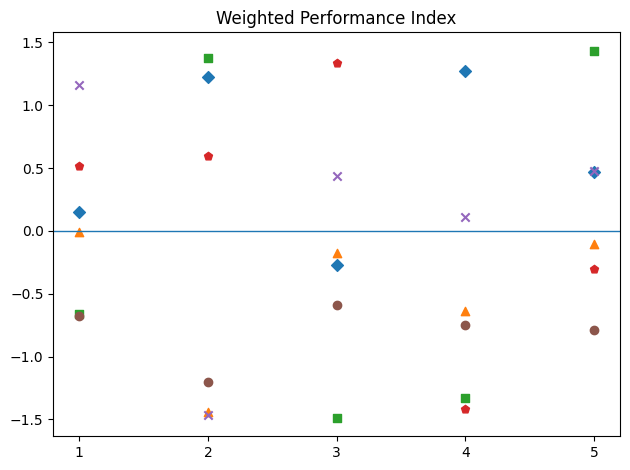

In [ ]:
#I will attempt to create teh weighted performance index 

import matplotlib.pyplot as plt

competitors = ["Our Business", "Competitor A", "Competitor B", "Competitor C", "Competitor D", "Competitor E"]
categories = ["1","2","3","4","5"]
x= np.arange(len(categories))
#create arrays for each competitor

data = {
    "Our Business": np.random.uniform(-1.50, 1.50, size = 5),
    "Competitor A": np.random.uniform(-1.50, 1.50, size = 5),
    "Competitor B": np.random.uniform(-1.50, 1.50, size = 5),
    "Competitor C": np.random.uniform(-1.50, 1.50, size = 5),
    "Competitor D": np.random.uniform(-1.50, 1.50, size = 5),
    "Competitor E": np.random.uniform(-1.50, 1.50, size = 5)
} 

#Due ot this being a dictionary so I will have to separate the x and y values
x_values=[]
y_values=[]


markers = {
    "Our Business": "D",
    "Competitor A": "^",
    "Competitor B": "s",
    "Competitor C": "p",
    "Competitor D": "x",
    "Competitor E": "o"
} 


for comp, y in data.items():
    plt.scatter(x, y, marker = markers[comp], label=comp)


plt.title("Weighted Performance Index")
plt.xticks(x, categories)
plt.axhline(0, linewidth=1)
#plt.legend()

plt.tight_layout()
